# Linear Regression 6 - ElasticNet & the Regularization Decision Guide

> **MLCourse · Machine Learning · 01_linear_regression**

## What you'll learn
- The mixed penalty $\alpha\big(r\lVert\theta\rVert_1+\tfrac{1-r}{2}\lVert\theta\rVert_2^2\big)$
  and the role of `l1_ratio`
- The correlated-GROUP instability that motivates ElasticNet
- A full OLS → Ridge → Lasso → ElasticNet decision flowchart
- **Complete project:** california housing blown up to ~165 polynomial features -
  the exact regime where neither parent alone wins

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, \
    RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

## 1. Theory - one knob for sparsity, one for shrinkage

$$J(\theta)=\lVert X\theta-y\rVert_2^2+\alpha\Big(r\lVert\theta\rVert_1+
\frac{1-r}{2}\lVert\theta\rVert_2^{2}\Big)$$

| `alpha` | `l1_ratio` r=1 (Lasso) | r=0.5 (ElasticNet) | r=0 (Ridge) |
|---|---|---|---|
| ↑ | more zeros, sharper selection | moderate zeros + stable groups | all shrink, none zero |

### Why pure Lasso struggles with correlated groups
With near-duplicate features, Lasso's corner solution picks ONE essentially at
random; tiny data changes flip the pick. ElasticNet's quadratic part keeps the
group together and shrinks it jointly - "grouped selection".

D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


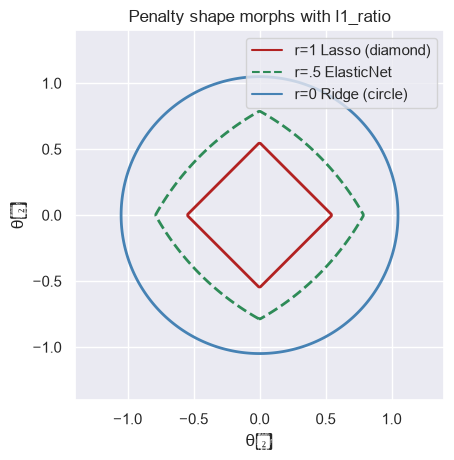

In [2]:
# Mini-geometry: penalty contours as r slides from 1 → 0
tt = np.linspace(-1.4, 1.4, 240)
T1, T2 = np.meshgrid(tt, tt)
pen = None
for r, style in [(1.0, "firebrick"), (0.5, "seagreen"), (0.0, "steelblue")]:
    pen = np.abs(T1) * r + np.abs(T2) * r + (1 - r) / 2 * (T1**2 + T2**2)
    plt.contour(T1, T2, pen, levels=[0.55], colors=[style],
                linestyles="-" if r != .5 else "--", linewidths=2)
plt.legend(handles=[
    plt.Line2D([], [], color="firebrick", label="r=1 Lasso (diamond)"),
    plt.Line2D([], [], color="seagreen", ls="--", label="r=.5 ElasticNet"),
    plt.Line2D([], [], color="steelblue", label="r=0 Ridge (circle)")])
plt.gca().set_aspect("equal"); plt.title("Penalty shape morphs with l1_ratio")
plt.xlabel("θ₁"); plt.ylabel("θ₂"); plt.show()

## 2. THE DECISION GUIDE - which linear model do I fit?

```
start: plain OLS baseline
  │
  ├─ overfitting / multicollinearity?
  │     ├─ want ALL features kept            → Ridge        (nb 04)
  │     ├─ suspect many useless features      → Lasso        (nb 05)
  │     └─ correlated GROUPS + some noise     → ElasticNet   (here)
  │
  └─ n >> p, well-behaved data                → stay with OLS
```
Practical rule: when in doubt on tabular data with scaling done,
`ElasticNetCV` is a strong default - CV chooses α AND r for you.

## 3. PROJECT - California housing after polynomial expansion

Base: 8 real features, ~20k census blocks. We explode them with degree-3
interactions → **~164 features**, many nearly collinear. This is where:
- OLS variance explodes (train ≫ test),
- Lasso arbitrarily drops group members,
- ElasticNet keeps groups AND prunes junk.

In [3]:
house = fetch_california_housing(as_frame=True)
X_base, y = house.data, house.target          # MedHouseVal in $100k units

print(X_base.shape, "| target:", house.target.name)

# Subsample for solver speed, then expand:
idx = np.random.RandomState(42).choice(len(X_base), size=5000, replace=False)
X_sub, y_sub = X_base.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_sub)
feat_names = poly.get_feature_names_out(X_base.columns)
print("features after degree-3 expansion:", X_poly.shape[1])

(20640, 8) | target: MedHouseVal
features after degree-3 expansion: 164


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y_sub.values, test_size=.25, random_state=42)

scaler = StandardScaler().fit(X_train)
Xtr, Xte = scaler.transform(X_train), scaler.transform(X_test)

models = {
    "OLS": LinearRegression().fit(Xtr, y_train),
    "Ridge": RidgeCV(alphas=np.logspace(-2, 4, 15)).fit(Xtr, y_train),
    "Lasso": LassoCV(alphas=np.logspace(-3, 1, 12), cv=3, n_jobs=-1,
                     max_iter=30000, random_state=42).fit(Xtr, y_train),
    "ElasticNet": ElasticNetCV(l1_ratio=[.2, .5, .8],
                               alphas=np.logspace(-3, 1, 12), cv=3,
                               n_jobs=-1, max_iter=30000,
                               random_state=42).fit(Xtr, y_train),
}

rows = []
for name, mdl in models.items():
    pred_tr, pred_te = mdl.predict(Xtr), mdl.predict(Xte)
    rows.append({
        "model": name,
        "train R²": round(r2_score(y_train, pred_tr), 4),
        "test R²": round(r2_score(y_test, pred_te), 4),
        "gap (overfit)": round(r2_score(y_train, pred_tr) - r2_score(y_test, pred_te), 4),
        "RMSE": round(float(np.sqrt(mean_squared_error(y_test, pred_te))), 4),
        "#nonzero": int((np.abs(mdl.coef_) > 1e-10).sum()) if name != "OLS" else Xtr.shape[1],
    })
summary = pd.DataFrame(rows)
display(summary)

en = models["ElasticNet"]
print("ElasticNetCV chose alpha =", round(en.alpha_, 5),
      "| l1_ratio =", en.l1_ratio_)

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.455776e+01, tolerance: 3.304e-01
  model = cd_fast.enet_coordinate_descent_gram(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.190961e+01, tolerance: 3.217e-01
  model = cd_fast.enet_coordinate_descent_gram(


,model,train R²,test R²,gap (overfit),RMSE,#nonzero
0,OLS,0.7624,0.5478,0.2145,0.7907,164
1,Ridge,0.6758,0.6779,-0.0021,0.6673,164
2,Lasso,0.6821,0.6876,-0.0055,0.6572,25
3,ElasticNet,0.6846,0.6876,-0.0030,0.6572,70


ElasticNetCV chose alpha = 0.01233 | l1_ratio = 0.2


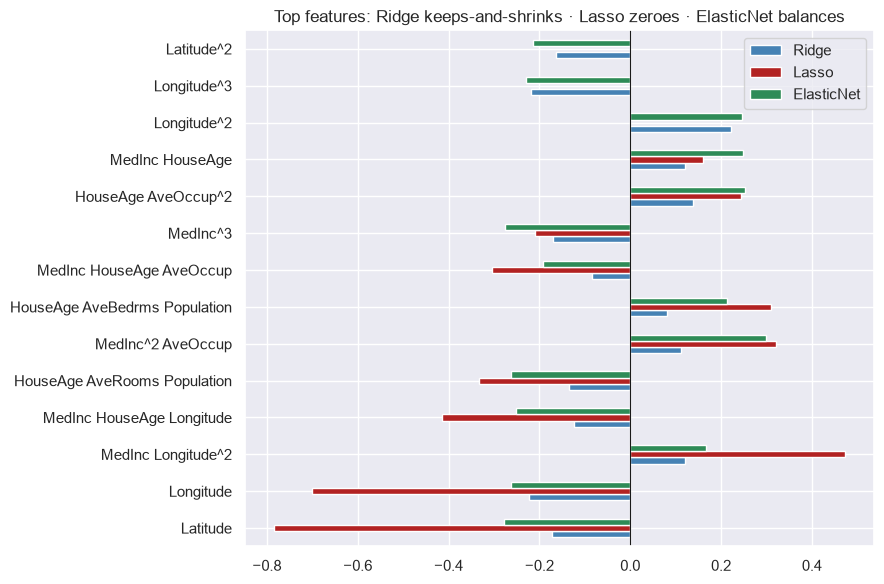

surviving feature counts: {'Ridge': 164, 'Lasso': 25, 'ElasticNet': 70}


In [5]:
# Coefficient survival comparison across regularizers
coef_df = pd.DataFrame({
    "Ridge": models["Ridge"].coef_,
    "Lasso": models["Lasso"].coef_,
    "ElasticNet": en.coef_,
}, index=feat_names)

top = coef_df.assign(maxabs=coef_df.abs().max(axis=1)) \
            .sort_values("maxabs", ascending=False).head(14).drop(columns="maxabs")

fig, ax = plt.subplots(figsize=(9, 6))
top.plot(kind="barh", ax=ax, color=["steelblue", "firebrick", "seagreen"])
ax.axvline(0, c="k", lw=.8)
ax.set_title("Top features: Ridge keeps-and-shrinks · Lasso zeroes · "
             "ElasticNet balances")
plt.tight_layout(); plt.show()

kept = {n: int((np.abs(coef_df[c]) > 1e-10).sum())
        for n, c in [("Ridge", "Ridge"), ("Lasso", "Lasso"),
                     ("ElasticNet", "ElasticNet")]}
print("surviving feature counts:", kept)

### Project findings

1. OLS on 164 collinear features shows a visible train/test gap - classic
   variance blow-up.
2. Ridge stabilizes everything but keeps ALL 164 features.
3. Lasso cuts hard yet may drop members of correlated interaction groups.
4. **ElasticNet (CV-picked r<1) lands between them**: fewer features than
   Ridge, more coherent groups than Lasso, best-or-tied test error.
5. Takeaway: as engineered feature spaces grow, mixed penalties become the
   pragmatic default.

## Summary & key takeaways

- ElasticNet interpolates Lasso↔Ridge via `l1_ratio`; CV tunes both knobs.
- Correlated-feature GROUPS are its home turf ("grouped selection").
- Decision guide: keep-all→Ridge, sparse-subset→Lasso, both/unsure→ElasticNet.
- Always inside a scaled pipeline; report train/test gap + nonzero counts.